In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import torch

torch.cuda.current_device() # returns 0 in my case

# get number of GPUs available
print("GPUs available ",torch.cuda.device_count()) # returns 1 in my case

# get the name of the device
torch.cuda.get_device_name(0) # good old Tesla K80

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
print(device)

In [4]:
#pobranie danych
#!wget bigbang.prz.edu.pl/starzyk/sequences_pawel.csv

In [33]:
#indeks obiektu to jego unikalny identyfikator
#kolumny to pozycje obiektow w scenie
#wartosci komorek to indesky obiektow
#każdy wiersz to jedna scena złożona z 10 obiektów, które określa indeks

df = pd.read_csv('sequences_przemek_2025-01.txt', sep=' ', header=None)
df

,0,1,2,3,4,5,6,7,8,9
0,3,112,432,578,713,938,539,654,307,568
1,5,600,177,142,781,33,654,956,67,659
2,8,144,942,276,362,118,126,104,734,812
3,9,278,579,542,152,572,753,506,984,585
4,10,139,759,299,39,436,642,634,643,763
...,...,...,...,...,...,...,...,...,...,...
495,993,18,324,753,582,88,52,491,446,810
496,994,949,901,401,152,778,7,735,305,602
497,995,887,606,72,256,621,110,138,789,580
498,996,284,460,535,316,456,399,59,555,612


In [34]:
#pandas to numpy array
data = df.to_numpy().copy()
print('Ile scen: '+str(data.shape[0]) +'\nLiczba obiektow w scenie: '+str(data.shape[1]))

Ile scen: 500
Liczba obiektow w scenie: 10


In [35]:
#wyglad tablicy
data[:,:]

array([[  3, 112, 432, ..., 654, 307, 568],
       [  5, 600, 177, ..., 956,  67, 659],
       [  8, 144, 942, ..., 104, 734, 812],
       ...,
       [995, 887, 606, ..., 138, 789, 580],
       [996, 284, 460, ...,  59, 555, 612],
       [999, 901,  69, ..., 489, 626, 339]])

In [36]:
print('Ile scen do zapamiętania (wiersze), z ilu obiektów składa się scena (kolumny): ',data.shape)
print('minimalny indeks: ',data.min())
print('maksymalny indeks', data.max())

#ile z 1000 indeksów użyto
#ile unikalnych obiektow w tablicy
print('Ile unikalnych indeksów', len(np.unique(data)))

Ile scen do zapamiętania (wiersze), z ilu obiektów składa się scena (kolumny):  (500, 10)
minimalny indeks:  0
maksymalny indeks 999
Ile unikalnych indeksów 992


In [37]:
np.unique(data)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

Od nowa numerujemy obiekty sceny, bo nie wszystkie indeksy moga byc wykorzystane

In [38]:
#obiekty tworzące scenę zostały wylosowane z zakresu liczb od 0 do 1000
print('Liczba unikalnych obiektów w scenach: ', len(np.unique(data)))
print('Ile obiektow bez przypisanej sceny: ',(data.max())-len(np.unique(data)))

Liczba unikalnych obiektów w scenach:  992
Ile obiektow bez przypisanej sceny:  7


In [39]:
data = df.to_numpy().copy()
#len(np.arange(2,len(np.unique(data))+2))

In [40]:
#obiekt o najniszym indeksie
print(data.min())
#obiekt o najwiekszym indeksie
print(data.max())

0
999


<b>Dodanie tokenów specjalnych</b>

Zwiększamy indeksy obiektów w scenach o 2, aby zrobić miejsce dla dwóch tokenów specjalnych.


- Token o <b>indeksie 0</b> reprezentuje token KOŃCA ODZYSKIWANIA SEKWENCJI


- Token o <b>indeksie 1</b> reprezentuje token RODZIELAJĄCY PODSEKWENCJE


<b>UWAGA:</b> Zwiększenie ma tylko sens jeśli token o najmniejszym indeksie ma wartość 0 lub 1.

In [41]:
offset = 0

if data.min() < 2:
    offset = 2 - data.min()
print('indeks kazdego obiektu w scenie ma być przesunięty o offset:', offset)

indeks kazdego obiektu w scenie ma być przesunięty o offset: 2


Poniższa komórka utworzy dwa słowniki:
- do zamiany numeru indeksu obiektu na indekst tokenu
- oraz na odwrót
- przenumeruje obiekty w tablicy <b>data</b> na indeksy tokenów

In [42]:
#stoi - string_to_index
#+2 pozwala zostawić dwa miejsca na token rozdzielajacy sekwencje '1'
#oraz token konca odzyskiwania sekwencji '0'
stoi = {(s+offset):(i) for i,s in zip( np.arange(2,len(np.unique(data))+2), np.unique(data) )}
stoi[0]=0
stoi[1]=1

#itos - index_to_string
#uwaga w itos sa uwzglednione dwa specjalne tokeny
#aby przywrocic oryginalna sekwencje, trzeba te tokeny odjac i przenumerowac slownik
itos = {i:s for s,i in stoi.items()}
itos[0]=0
itos[1]=1


i = 0
for ii in range(0,data.shape[0]):
    for jj in range(0, data.shape[1]):
        data[ii,jj]=stoi[data[ii,jj]+offset]

#WYGLAD SCEN PO PRZENUMEROWANIU
data

array([[  5, 113, 432, ..., 651, 308, 567],
       [  7, 597, 178, ..., 950,  68, 656],
       [ 10, 145, 937, ..., 105, 731, 807],
       ...,
       [989, 882, 603, ..., 139, 785, 579],
       [990, 285, 460, ...,  60, 555, 609],
       [993, 896,  70, ..., 489, 623, 340]])

Zawartość słownika <b>OBIEKT -> TOKEN</b>

In [43]:
stoi

{2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 16: 16,
 17: 17,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 25,
 27: 26,
 28: 27,
 29: 28,
 30: 29,
 31: 30,
 32: 31,
 33: 32,
 34: 33,
 35: 34,
 36: 35,
 37: 36,
 38: 37,
 39: 38,
 40: 39,
 41: 40,
 42: 41,
 43: 42,
 44: 43,
 45: 44,
 46: 45,
 47: 46,
 48: 47,
 49: 48,
 50: 49,
 51: 50,
 52: 51,
 53: 52,
 54: 53,
 55: 54,
 56: 55,
 57: 56,
 58: 57,
 59: 58,
 60: 59,
 61: 60,
 62: 61,
 63: 62,
 64: 63,
 65: 64,
 66: 65,
 67: 66,
 68: 67,
 69: 68,
 70: 69,
 71: 70,
 72: 71,
 73: 72,
 74: 73,
 75: 74,
 76: 75,
 77: 76,
 78: 77,
 79: 78,
 80: 79,
 81: 80,
 82: 81,
 83: 82,
 84: 83,
 85: 84,
 86: 85,
 87: 86,
 88: 87,
 89: 88,
 90: 89,
 91: 90,
 92: 91,
 93: 92,
 94: 93,
 95: 94,
 96: 95,
 97: 96,
 98: 97,
 99: 98,
 100: 99,
 101: 100,
 102: 101,
 103: 102,
 104: 103,
 105: 104,
 106: 105,
 107: 106,
 108: 107,
 109: 108,
 110: 109,
 111: 110,
 112: 111,
 

Zawartość słownika <b>TOKEN -> OBIEKT</b>

In [44]:
itos

{2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 16: 16,
 17: 17,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 25,
 26: 27,
 27: 28,
 28: 29,
 29: 30,
 30: 31,
 31: 32,
 32: 33,
 33: 34,
 34: 35,
 35: 36,
 36: 37,
 37: 38,
 38: 39,
 39: 40,
 40: 41,
 41: 42,
 42: 43,
 43: 44,
 44: 45,
 45: 46,
 46: 47,
 47: 48,
 48: 49,
 49: 50,
 50: 51,
 51: 52,
 52: 53,
 53: 54,
 54: 55,
 55: 56,
 56: 57,
 57: 58,
 58: 59,
 59: 60,
 60: 61,
 61: 62,
 62: 63,
 63: 64,
 64: 65,
 65: 66,
 66: 67,
 67: 68,
 68: 69,
 69: 70,
 70: 71,
 71: 72,
 72: 73,
 73: 74,
 74: 75,
 75: 76,
 76: 77,
 77: 78,
 78: 79,
 79: 80,
 80: 81,
 81: 82,
 82: 83,
 83: 84,
 84: 85,
 85: 86,
 86: 87,
 87: 88,
 88: 89,
 89: 90,
 90: 91,
 91: 92,
 92: 93,
 93: 94,
 94: 95,
 95: 96,
 96: 97,
 97: 98,
 98: 99,
 99: 100,
 100: 101,
 101: 102,
 102: 103,
 103: 104,
 104: 105,
 105: 106,
 106: 107,
 107: 108,
 108: 109,
 109: 110,
 110: 111,
 111: 112,
 

Generujemy slownik ze scenami, narazie bez TOKENU ROZDZIELAJACEGO oraz STOPU

In [45]:
#end_sign = np.zeros(shape=(1,1))-1
sequence_length = []
scenes_dict={}

data_orginal = df.to_numpy().copy()

for row in range(0, data.shape[0]):
    #dodajemy + 2 do indeksow obiektow w scenie
    #aby tokeny 0 i 1 mogly reprezentowaly znaki
    #1 - rozdzielenia sceny  oraz 0 - konca odtwarzania sceny
    scenes_dict[row]=list((data[row,:]))

    
print("scena oryginalna:")
#Przykładowa scena    
for i in range(data.shape[1]):
    print(data_orginal[0][i], end=" ")
    
print("\n\nscena po przenumerowaniu aby uwgzlędnić dwa dodatkowe tokeny PRZECINEK, STOP:")
#Przykładowa scena    
for i in range(data.shape[1]):
    print(scenes_dict[0][i], end=" ")

scena oryginalna:
3 112 432 578 713 938 539 654 307 568 

scena po przenumerowaniu aby uwgzlędnić dwa dodatkowe tokeny PRZECINEK, STOP:
5 113 432 577 710 933 539 651 308 567 

<b>Generowanie sekwencji odzyskiwania scen</b>

In [46]:
print('Liczba scen w sloniku scenes_dict:', len(scenes_dict))

Liczba scen w sloniku scenes_dict: 500


In [47]:
#funkcja do usuwania losowych elementów ze sceny
import random

def remove_random_elements_copy(ordered_list, how_many_elements_to_remove):
    # Calculate the length of the list
    list_length = len(ordered_list)

    # Generate unique random indices to remove elements from the list
    indices_to_remove = random.sample(range(list_length), how_many_elements_to_remove)

    # Create a new list without the selected elements
    new_list = [element for i, element in enumerate(ordered_list) if i not in indices_to_remove]

    return new_list

Funkcja która generuje przykłady uczące przez stopniowe:

- usuwanie losowych elementów z sekwencji
- zamianę miejscami dwóch losowo wybranych tokenów

In [48]:
max_number_of_elements_to_remove = 1
min_elements_of_list = 3

chance_to_swap_indexes_of_two_elements = 0.15

def generate_examples_of_subsequence_restoration():
    scenes_dict_scene_sequential_restoration={}

    #i=0
    for key in scenes_dict.keys():
        tmp_list = []
        #print(scenes_dict[key])
        #print("\r"+str(key), end=' ')
        tmp_list.append( scenes_dict[key])

        new_list = scenes_dict[key]

        # Ensure that there are at least X elements in the list

        while len(new_list) > min_elements_of_list:
            
            how_many_elements_to_remove = random.randint(1, max_number_of_elements_to_remove)
            
            #tym ifem zapewniamy że najkrotsza lista bedzie miala dlugosc okreslona
            #przez parametr min_elements_of_list
            if (len(new_list)-how_many_elements_to_remove)< min_elements_of_list:
                  how_many_elements_to_remove = len(new_list) - min_elements_of_list
            
            #print(new_list)
            new_list = remove_random_elements_copy(new_list, how_many_elements_to_remove )

            # Swap the elements at the random indices
            if random.random() < chance_to_swap_indexes_of_two_elements:
                index1 = random.randint(0, len(new_list) - 1)
                index2 = random.randint(0, len(new_list) - 1)
                #podmieniamy elementy
                new_list[index1], new_list[index2] = new_list[index2], new_list[index1]

            tmp_list.append(new_list)

        scenes_dict_scene_sequential_restoration[key] = tmp_list
        #i=i+1

    return scenes_dict_scene_sequential_restoration

Generowanie sekwencji pokazujących jak odzyskać scenę

In [49]:
scenes_dict_scene_sequential_restoration = generate_examples_of_subsequence_restoration()
len(scenes_dict_scene_sequential_restoration)
slownik = scenes_dict_scene_sequential_restoration

#przyklad sekwencji do nauki sieci, 
#patrzymy od dolnego wiersza do gory
#pierwszy wiersz to pelna sekwencja do odzyskania
#ostatni to punkt startowy

print('Przykład odzyskiwania sekwencji w słowniku pod indeksem 0')
print(slownik[0])
print('\n')

print('Wersja bardziej czytelna:\n')

for item in slownik[0]:
    
    for element in item:
        print(element, end=' ')
    print('\n')
#Sekwencję odzyskuje się idąc od dołu do góry

Przykład odzyskiwania sekwencji w słowniku pod indeksem 0
[[5, 113, 432, 577, 710, 933, 539, 651, 308, 567], [113, 432, 577, 710, 933, 539, 651, 308, 567], [113, 432, 710, 308, 539, 651, 933, 567], [113, 432, 710, 308, 651, 933, 567], [113, 432, 710, 308, 933, 567], [113, 432, 308, 933, 567], [113, 308, 933, 567], [308, 933, 567]]


Wersja bardziej czytelna:

5 113 432 577 710 933 539 651 308 567 

113 432 577 710 933 539 651 308 567 

113 432 710 308 539 651 933 567 

113 432 710 308 651 933 567 

113 432 710 308 933 567 

113 432 308 933 567 

113 308 933 567 

308 933 567 



Losowa sekwencja ze słownika

In [99]:
index_of_random_exmaple = random.randint(1, len(slownik))

print('Losowa sekwencja')
for item in slownik[index_of_random_exmaple]:
    for element in item:
        print(element, end=' ')
    print('\n')
    
#SEKWENCJA ODZYSKIWANA JEST Z DOŁU DO GÓRY

Losowa sekwencja
222 65 798 736 712 630 731 79 640 279 

222 65 798 712 630 731 79 640 279 

222 65 798 712 630 731 640 279 

222 65 798 712 630 731 640 

222 65 798 712 630 731 

222 65 798 712 630 

222 798 712 630 

222 712 630 



Generacja tablicy z odzyskiwaniem sekwencji do nauki (kolejne 2 komórki)

In [101]:
for i in range(0,1):
    trainig_array = generate_training_array( generate_examples_of_subsequence_restoration() )
    val_array = generate_training_array( generate_examples_of_subsequence_restoration() )
    
    if i==0:
        trainig_array_all = trainig_array.copy()
        val_array_all = val_array.copy()
    else:
        trainig_array_all = np.hstack((trainig_array_all, trainig_array))
        val_array_all = np.hstack((val_array_all, val_array))

trainig_array_all = np.reshape(trainig_array_all, (trainig_array_all.shape[0],))
train_data = torch.tensor(trainig_array_all, dtype=torch.long)

all_sequences = np.reshape(val_array_all, (val_array_all.shape[0],))
val_data = torch.tensor(val_array_all, dtype=torch.long)


print(all_sequences.shape)
print(train_data.shape)
print(val_data.shape)

(30001,)
torch.Size([30001])
torch.Size([30001])


In [102]:
print(train_data[0:75])
print(val_data[0:75])

tensor([  0, 567, 539, 651,   1, 567, 539, 651,   5,   1, 308, 567, 539, 651,
          5,   1, 308, 567, 539, 651,   5, 577,   1, 308, 567, 710, 539, 651,
          5, 577,   1,   5, 113, 567, 710, 539, 651, 308, 577,   1,   5, 113,
        577, 710, 933, 539, 651, 308, 567,   1,   5, 113, 432, 577, 710, 933,
        539, 651, 308, 567,   0, 651,  34,   7,   1, 651, 777,  34,   7,   1,
          7, 777,  34, 651,  68])
tensor([  0,   5, 651, 113,   1,   5, 432, 651, 113,   1,   5, 308, 432, 651,
        113,   1,   5, 113, 432, 539, 651, 308,   1,   5, 113, 432, 539, 651,
        308, 567,   1,   5, 113, 432, 710, 539, 651, 308, 567,   1,   5, 113,
        432, 577, 710, 539, 651, 308, 567,   1,   5, 113, 432, 577, 710, 933,
        539, 651, 308, 567,   0, 178, 597, 143,   1, 178, 597, 143,  68,   1,
        777, 178, 143, 597,  68])


In [103]:
scenes_dict_scene_sequential_restoration

{0: [[5, 113, 432, 577, 710, 933, 539, 651, 308, 567],
  [113, 432, 577, 710, 933, 539, 651, 308, 567],
  [113, 432, 710, 308, 539, 651, 933, 567],
  [113, 432, 710, 308, 651, 933, 567],
  [113, 432, 710, 308, 933, 567],
  [113, 432, 308, 933, 567],
  [113, 308, 933, 567],
  [308, 933, 567]],
 1: [[7, 597, 178, 143, 777, 34, 651, 950, 68, 656],
  [7, 597, 178, 143, 777, 34, 950, 68, 656],
  [7, 597, 143, 777, 34, 950, 68, 656],
  [7, 597, 143, 777, 34, 950, 656],
  [7, 597, 143, 34, 950, 656],
  [7, 143, 34, 950, 656],
  [7, 143, 34, 656],
  [7, 34, 656]],
 2: [[10, 145, 937, 277, 363, 119, 127, 105, 731, 807],
  [10, 145, 937, 277, 363, 119, 127, 731, 807],
  [10, 145, 937, 277, 363, 119, 731, 807],
  [10, 145, 277, 363, 119, 731, 807],
  [10, 145, 277, 119, 731, 807],
  [10, 145, 277, 119, 807],
  [10, 277, 119, 807],
  [10, 119, 807]],
 3: [[11, 279, 578, 542, 153, 571, 750, 506, 978, 584],
  [11, 279, 578, 542, 153, 571, 506, 978, 584],
  [11, 279, 578, 542, 153, 571, 506, 584],
  

In [53]:
#ZERO TO KONIEC SEKWENCJI
end_sign_seqence_restored = np.zeros(shape=(1))
#JEDEN TO ZNAK RODZIELAJACY PODSEKWENCJE
end_sign_of_subseqence = np.ones(shape=(1))

def generate_training_array(scenes_dict_scene_sequential_restoration):
    sequence_length = []
    scenes_dict={}

    for key in scenes_dict_scene_sequential_restoration:
        #print("\r"+str(key), end=' ') 
        if key==0: 
            all_sequences = np.zeros(shape=(1))
        else:
            all_sequences =  np.hstack((all_sequences, end_sign_seqence_restored))

        for i in range( len(scenes_dict_scene_sequential_restoration[key])-1, -1, -1):
            subsequence = scenes_dict_scene_sequential_restoration[key][i]
            
            #print(i)
            #print(len(scenes_dict_scene_sequential_restoration[key]))
            if i > 0:
                all_sequences =  np.hstack((all_sequences, subsequence, end_sign_of_subseqence))
            else:
                all_sequences =  np.hstack((all_sequences, subsequence))
            #print('x')

    all_sequences =  np.hstack((all_sequences, end_sign_seqence_restored))
    
    return all_sequences

In [104]:
train_data[:400]

torch.Size([30001])

557 752 287 811 611 586 897 879 655 639 447  27 170 394 236 161 194 117
 761 626 598  91 194 146 435

Poniższy kod generuje slownik ze scenami zapisanymi tak ze kazda scena ma jedna dlugosc

[ 10, 100, 257, 258, 262, 270, 294, 356, 480, 482, 486, 496, 529, 530, 542, 598, 626, 850, 868, 943, 983, 1024, 1092, -1, -1, -1]

In [55]:
'''
data = df.to_numpy()
print('Ile scen: '+str(data.shape[0]) +'\nLiczba obiektow w scenie: '+str(data.shape[1]))

end_sign = np.zeros(shape=(1,1))-1
sequence_length = []
scenes_dict={}

for row in range(0, data.shape[0]):
    sequence = np.where(data[row,:]==1)
    scenes_dict[row]=sequence[0]

    sequence_length.append(sequence[0].shape[0])
    zeros_to_add = 26 - sequence_length[-1]
    sequence = np.hstack((sequence, (np.zeros(shape=(1, zeros_to_add))-1)))
    if row == 0:
        all_sequences = sequence.copy()
    else:
        all_sequences = np.hstack((all_sequences, sequence ))
'''

"\ndata = df.to_numpy()\nprint('Ile scen: '+str(data.shape[0]) +'\nLiczba obiektow w scenie: '+str(data.shape[1]))\n\nend_sign = np.zeros(shape=(1,1))-1\nsequence_length = []\nscenes_dict={}\n\nfor row in range(0, data.shape[0]):\n    sequence = np.where(data[row,:]==1)\n    scenes_dict[row]=sequence[0]\n\n    sequence_length.append(sequence[0].shape[0])\n    zeros_to_add = 26 - sequence_length[-1]\n    sequence = np.hstack((sequence, (np.zeros(shape=(1, zeros_to_add))-1)))\n    if row == 0:\n        all_sequences = sequence.copy()\n    else:\n        all_sequences = np.hstack((all_sequences, sequence ))\n"

In [56]:
'''
#Scena z minimalna liczba obiektow
min(sequence_length)
'''

'\n#Scena z minimalna liczba obiektow\nmin(sequence_length)\n'

In [57]:
'''
import matplotlib.pyplot as plt

counts, bins = np.histogram(sequence_length)
print(counts)
print(bins)
plt.hist(sequence_length,fill=True)
#plt.stairs(counts, bins, fill=True)
'''

'\nimport matplotlib.pyplot as plt\n\ncounts, bins = np.histogram(sequence_length)\nprint(counts)\nprint(bins)\nplt.hist(sequence_length,fill=True)\n#plt.stairs(counts, bins, fill=True)\n'

In [58]:
#pierwsza scena wyglada tak
scenes_dict[0]

[5, 113, 432, 577, 710, 933, 539, 651, 308, 567]

In [59]:
from random import sample

In [60]:
np.set_printoptions(suppress=True)

In [61]:
np.set_printoptions(suppress=False)
#ROZMIAR TABLICY UCZACEJ
print(all_sequences.shape)

all_sequences

(30001,)


array([  0., 710., 933., ..., 623., 340.,   0.])

Dane testowe zawierają 1000 scen, gdzie każda składa się z 25 obiektów. Wszystkich możliwych obiektów jest 1104 + 1(znak rozdzielajacy zero)

Tutaj generujemy wstazke pelnych scen, rozdzielone znakiem 0


In [62]:
scenes_dict[0]

[5, 113, 432, 577, 710, 933, 539, 651, 308, 567]

In [63]:
'''
data = df.to_numpy()
print('Ile scen: '+str(data.shape[0]) +'\nLiczba obiektow w scenie: '+str(data.shape[1])+'+1')

end_sign = np.zeros(shape=(1,1))-1
scenes_dict={}

for row in range(0, data.shape[0]):
    sequence = np.where(data[row,:]==1)
    #scenes_dict[row]=sequence[0]

    sequence = np.hstack((sequence, end_sign))

    if row == 0:
        all_sequences = sequence.copy()
    else:
        all_sequences = np.hstack((all_sequences, sequence ))

#znak rozdzielajacy sceny zmieniamy z -1 na 0
#numery wszystkich obiektow zwiekszamy o jeden
all_sequences = all_sequences +1
'''

"\ndata = df.to_numpy()\nprint('Ile scen: '+str(data.shape[0]) +'\nLiczba obiektow w scenie: '+str(data.shape[1])+'+1')\n\nend_sign = np.zeros(shape=(1,1))-1\nscenes_dict={}\n\nfor row in range(0, data.shape[0]):\n    sequence = np.where(data[row,:]==1)\n    #scenes_dict[row]=sequence[0]\n\n    sequence = np.hstack((sequence, end_sign))\n\n    if row == 0:\n        all_sequences = sequence.copy()\n    else:\n        all_sequences = np.hstack((all_sequences, sequence ))\n\n#znak rozdzielajacy sceny zmieniamy z -1 na 0\n#numery wszystkich obiektow zwiekszamy o jeden\nall_sequences = all_sequences +1\n"

In [64]:
'''
print(all_sequences.shape)
all_sequences_flattened = np.reshape(all_sequences, (all_sequences.shape[1],))
data = torch.tensor(all_sequences_flattened, dtype=torch.long)
'''

'\nprint(all_sequences.shape)\nall_sequences_flattened = np.reshape(all_sequences, (all_sequences.shape[1],))\ndata = torch.tensor(all_sequences_flattened, dtype=torch.long)\n'

In [65]:
'''
#all_sequences_flattened = np.reshape(all_sequences, (all_sequences.shape[1],))
data = torch.tensor(all_sequences, dtype=torch.long)
'''

'\n#all_sequences_flattened = np.reshape(all_sequences, (all_sequences.shape[1],))\ndata = torch.tensor(all_sequences, dtype=torch.long)\n'

In [66]:
'''
data.shape
'''

'\ndata.shape\n'

In [67]:
import torch
import random
from random import sample
batch_size=8
block_size=100
#scene_context_size = 15

In [68]:
# DLA SCEN W FORMIE WSTAZKI
# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    
    return x, y

In [69]:
#MOZNA POPRAWIC ABY GETBATCH ZACZYNAL ZAWSZE KOLEJNEGO OD ZNAKU PO TOKENIE PRZECINKA (INDEKS 1), 
#ALE TEGO TOKENU NIE BRAL POD UWAGE
get_batch('train')

(tensor([[531,   1, 266, 157, 790, 704, 259, 704, 768, 531,   1, 266, 157, 790,
          704, 259, 948, 704, 768, 531,   1, 266, 157, 790, 244, 704, 259, 948,
          704, 768, 531,   0, 644, 159, 215,   1, 908, 644, 159, 215,   1, 908,
          215, 159, 979, 644,   1, 908, 215, 159, 979, 824, 644,   1, 908, 215,
          159,  24, 979, 824, 644,   1, 908, 215, 792, 159,  24, 979, 824, 644,
            1, 266, 215, 908, 792, 159,  24, 979, 824, 644,   1, 266, 215, 908,
          792, 159,  24, 979, 854, 824, 644,   0, 266, 896, 330,   1, 266, 411,
          896, 330],
         [298, 758, 181,   0, 769, 931, 752,   1, 931, 769, 752, 133,   1, 931,
          769, 752, 848, 133,   1, 931, 769, 752, 848, 108, 133,   1, 931, 455,
          769, 752, 848, 108, 133,   1, 536, 931, 455, 769, 752, 848, 108, 133,
            1, 536, 619, 931, 455, 769, 752, 848, 108, 133,   1, 536, 619, 931,
          455, 359, 769, 752, 848, 108, 133,   0, 537, 166, 189,   1, 537, 166,
          189, 101,

In [70]:
'''
# data loading
def get_batch():
    # generate a small batch of data of inputs x and targets y

    x = np.zeros(shape=(batch_size, block_size))
    y = np.zeros(shape=(batch_size, block_size))

    for i in range(0, batch_size):

        ix = random.randint(0, int(len(scenes_dict)-1))

        random_list = (sample(list(scenes_dict[ix]), scene_context_size))
        random_list.sort()

        x[i, :scene_context_size] = np.array(random_list)
        y[i, :sequence_length[ix]] = scenes_dict[ix]
    #print(ix)
    #print(x)
    #print(y)

    x = torch.tensor(x, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.long)
    x, y = x.to(device), y.to(device)
    return x,y
#x, y = get_batch()
#len(all_sequences)
'''

'\n# data loading\ndef get_batch():\n    # generate a small batch of data of inputs x and targets y\n\n    x = np.zeros(shape=(batch_size, block_size))\n    y = np.zeros(shape=(batch_size, block_size))\n\n    for i in range(0, batch_size):\n\n        ix = random.randint(0, int(len(scenes_dict)-1))\n\n        random_list = (sample(list(scenes_dict[ix]), scene_context_size))\n        random_list.sort()\n\n        x[i, :scene_context_size] = np.array(random_list)\n        y[i, :sequence_length[ix]] = scenes_dict[ix]\n    #print(ix)\n    #print(x)\n    #print(y)\n\n    x = torch.tensor(x, dtype=torch.long)\n    y = torch.tensor(y, dtype=torch.long)\n    x, y = x.to(device), y.to(device)\n    return x,y\n#x, y = get_batch()\n#len(all_sequences)\n'

In [71]:
'''
# data loading
def get_batch():
    # generate a small batch of data of inputs x and targets y

    x = np.zeros(shape=(batch_size, block_size))
    y = np.zeros(shape=(batch_size, block_size))

    for i in range(0, batch_size):

        ix = random.randint(0, int(len(scenes_dict)-1))

        #random_list = (sample(list(scenes_dict[ix]), scene_context_size))
        #random_list.sort()

        x[i, :sequence_length[ix]] = scenes_dict[ix]
        y[i, :sequence_length[ix]] = scenes_dict[ix]
    #print(ix)
    #print(x)
    #print(y)

    x = torch.tensor(x, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.long)
    x, y = x.to(device), y.to(device)
    return x,y
'''

'\n# data loading\ndef get_batch():\n    # generate a small batch of data of inputs x and targets y\n\n    x = np.zeros(shape=(batch_size, block_size))\n    y = np.zeros(shape=(batch_size, block_size))\n\n    for i in range(0, batch_size):\n\n        ix = random.randint(0, int(len(scenes_dict)-1))\n\n        #random_list = (sample(list(scenes_dict[ix]), scene_context_size))\n        #random_list.sort()\n\n        x[i, :sequence_length[ix]] = scenes_dict[ix]\n        y[i, :sequence_length[ix]] = scenes_dict[ix]\n    #print(ix)\n    #print(x)\n    #print(y)\n\n    x = torch.tensor(x, dtype=torch.long)\n    y = torch.tensor(y, dtype=torch.long)\n    x, y = x.to(device), y.to(device)\n    return x,y\n'

In [72]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
#batch_size = 16 # how many independent sequences will we process in parallel?
#block_size = 25 # what is the maximum context length for predictions?
#max_iters = 5000
eval_interval = 500
learning_rate = 1e-3

eval_iters = 10
n_embd = 180
n_head = 6
n_layer = 6
dropout = 0.3
# ------------

#pierwsze podejscie 
n_embd = 180 
n_head = 6
n_layer = 6
dropout = 0.2



In [73]:
# data loading
print('Rozmiar slownika:', len(stoi))
vocab_size = len(stoi)
batch_size = 128

Rozmiar slownika: 994


In [74]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context

        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

loss_history=[]
val_history=[]
learning_rate_hist=[]
batch_size_hist=[]

2.720794 M parameters


In [75]:
#train_data = data[:]
#val_data = data[:]

loss_history=[]
val_history=[]
learning_rate_hist=[]
batch_size_hist=[]

In [81]:
#block size orkesla dlugosc sekwencji, 
block_size = 100
batch_size = 512

In [82]:
#batch_size i block_size sa przekazywane niewprost do funkcji generujacej batche get_batch

In [83]:
from timeit import default_timer as timer

from IPython.display import display, clear_output

learning_rate = 5e-4 #1e-3
eval_interval = 1000
down_scale_epoch_factor = 10


for epoch in range(0,1500):
    learning_rate_hist.append(learning_rate)
    batch_size_hist.append(batch_size)
    
    if epoch % (30) == 0:
        clear_output(wait=True)
            
    print("Epoch "+str(epoch)+" generating train and val data")
    for i in range(0,1000):
        trainig_array = generate_training_array( generate_examples_of_subsequence_restoration() )
        if i==0:
            trainig_array_all = trainig_array.copy()
        else:
            trainig_array_all = np.hstack((trainig_array_all, trainig_array))

        trainig_array_all = np.reshape(trainig_array_all, (trainig_array_all.shape[0],))
        train_data = torch.tensor(trainig_array_all, dtype=torch.long)

    for i in range(0,250):
        val_array = generate_training_array( generate_examples_of_subsequence_restoration() )
        if i==0:
            val_array_all = val_array.copy()
        else:                
            val_array_all = np.hstack((val_array_all, val_array))

        val_array_all = np.reshape(val_array_all, (val_array_all.shape[0],))
        val_data = torch.tensor(val_array_all, dtype=torch.long)    

    for iter in range(int(train_data.shape[0] / batch_size / down_scale_epoch_factor)):
        # every once in a while evaluate the loss on train and val sets
        if iter % eval_interval == 0:
            time_start = timer()
            losses = estimate_loss()
            duration = timer() - time_start
            print(f"Epoch {epoch}: step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}, time {duration:.6f}")
                  
            loss_history.append(losses['train'])
            val_history.append(losses['val'])
            
   
        # sample a batch of data
        xb, yb = get_batch('train')

        # evaluate the loss
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    
    epoch = epoch + 1
    # generate from the model
    #context = torch.zeros((1, 1), dtype=torch.long, device=device)
    #print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))

Epoch 30 generating train and val data
Epoch 30: step 0: train loss 0.4053, val loss 0.4063, time 2.211943
Epoch 30: step 1000: train loss 0.4044, val loss 0.4059, time 2.176295
Epoch 30: step 2000: train loss 0.4047, val loss 0.4071, time 2.178979
Epoch 30: step 3000: train loss 0.4016, val loss 0.4065, time 2.177904
Epoch 30: step 4000: train loss 0.4021, val loss 0.4065, time 2.178824
Epoch 30: step 5000: train loss 0.4020, val loss 0.4079, time 2.206283
Epoch 31 generating train and val data
Epoch 31: step 0: train loss 0.4050, val loss 0.4065, time 2.180043
Epoch 31: step 1000: train loss 0.4005, val loss 0.4066, time 2.179420
Epoch 31: step 2000: train loss 0.4008, val loss 0.4064, time 2.179214
Epoch 31: step 3000: train loss 0.4033, val loss 0.4055, time 2.180079
Epoch 31: step 4000: train loss 0.4005, val loss 0.4064, time 2.179135
Epoch 31: step 5000: train loss 0.4017, val loss 0.4069, time 2.178195
Epoch 32 generating train and val data
Epoch 32: step 0: train loss 0.4055, 

KeyboardInterrupt: 

In [84]:
#czy batch dziala

#dlugosc sekwencji
print(xb[0,:])

tensor([504, 702, 610, 813, 877, 333,   1, 675, 315,  44, 504, 702, 928, 610,
        813, 877, 333,   0, 678, 286, 922,   1, 678, 901, 286, 922,   1, 678,
        922, 196, 286, 901,   1, 678, 922, 196, 286, 479, 901,   1, 678, 922,
        196, 286, 479, 901, 349,   1, 678, 922, 196,  51, 286, 479, 901, 349,
          1, 678, 922, 196,  51, 286, 479, 901, 422, 349,   1, 678, 922,  31,
        196,  51, 286, 479, 901, 422, 349,   0, 509, 326, 121,   1, 509, 680,
        326, 121,   1, 509, 523, 680, 326, 121,   1, 412, 509, 523, 680, 326,
        121,   1], device='cuda:0')


In [56]:
#len(batch_size_hist)
#len(loss_history)
print(batch_size)
print(train_data.shape[0] / batch_size)

2
15000500.0


In [57]:
int(train_data.shape[0] / batch_size)

15000500

# Loss & Val_loss, batch_size, learning_rate plots

In [86]:
len(loss_history)

241

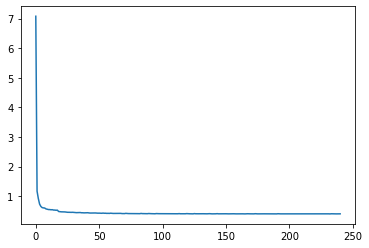

In [89]:
plt.plot(loss_history)

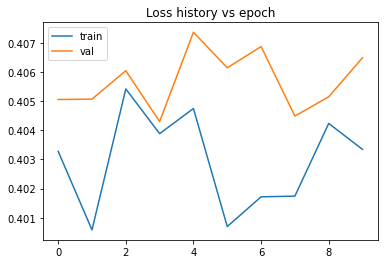

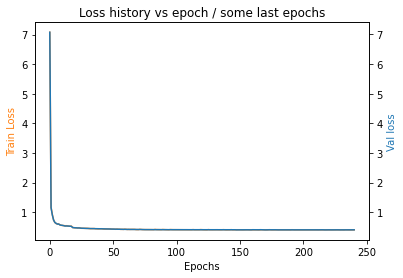

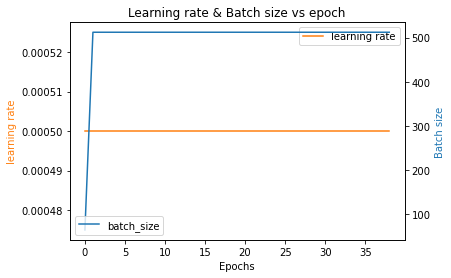

In [92]:
import matplotlib.pyplot as plt

plt.gcf().set_facecolor('white')

plt.title("Loss history vs epoch")
plt.plot(loss_history[-10:], label='train')
#plt.savefig('loss_history.png')
#plt.title("Validation Loss history vs epoch")
plt.plot(val_history[-10:], label="val")
plt.legend()
#plt.gcf().set_facecolor('white')
#plt.savefig('loss_history.png')

plt.show()

how_many_epochs_back = 241

#TRAIN LOSS & VAL LOSS - some few epochs
if len(loss_history)>10:
    fig, ax1 = plt.subplots()
    
    plt.title("Loss history vs epoch / some last epochs")
    ax1.plot(loss_history[-how_many_epochs_back:], color='tab:orange', label='train loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Train Loss', color='tab:orange')
    
    #plt.gcf().set_facecolor('white')
    #plt.savefig('loss_history_500_last_epochs.png')
       
    ax2 = ax1.twinx()

    #plt.title("Validation Loss history vs epoch / last 500 epochs")
    ax2.plot(val_history[-how_many_epochs_back:], color='tab:blue', label='batch_size')
    ax2.set_ylabel('Val loss', color='tab:blue')
    
    # Customize appearance
    ax1.tick_params(axis='y', colors='black')
    ax2.tick_params(axis='y', colors='black')

    plt.gcf().set_facecolor('white')
    #plt.savefig('val_history_500_last_epochs.png')
    plt.show()

    
#LEARNING RATE & BATCH SIZE
#LEARNING RATE & BATCH SIZE
#LEARNING RATE & BATCH SIZE
fig, ax1 = plt.subplots()
ax1.plot(learning_rate_hist[:], color='tab:orange', label='learning rate')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('learning rate', color='tab:orange')

# Create a second set of axes that shares the same x-axis as the first one
ax2 = ax1.twinx()
# Plot the second dataset on the second set of axes
ax2.plot(batch_size_hist[:], color='tab:blue', label='batch_size')
ax2.set_ylabel('Batch size', color='tab:blue')

# Customize appearance
ax1.tick_params(axis='y', colors='black')
ax2.tick_params(axis='y', colors='black')

plt.title("Learning rate & Batch size vs epoch")
#plt.plot(learning_rate_hist[:])
plt.gcf().set_facecolor('white')
#plt.savefig('learning_rate_hist.png')
# Add legend
ax1.legend(loc='best')
ax2.legend(loc='lower left')

plt.show()


#plt.title("Batch size vs epoch")
#plt.plot(batch_size_hist[:])
#plt.gcf().set_facecolor('white')
#plt.savefig('batch_size_hist.png')
#plt.show()

# ZAPIS list z historia uczenia do pliku

In [85]:
lists_to_save = [loss_history, val_history, learning_rate_hist, batch_size_hist]
lists_file_names = ['loss_history','val_history', 'lr_history', 'batch_size_hist']

for a_list, list_file_name in zip(lists_to_save, lists_file_names):
    with open(list_file_name + '.txt','w') as file:
        file.write('\n'.join(map(str, a_list)))

In [86]:
print("scena do originalna")
for item in df.to_numpy()[0,:]:
    print(item, end=" ")
print('\n\nscena do nauki')
for item in scenes_dict[0]:
    print(item, end=" ")

scena do originalna
3 112 432 578 713 938 539 654 307 568 

scena do nauki
5 113 432 577 710 933 539 651 308 567 

In [60]:
scenes_dict[124]

[239, 41, 404, 386, 392, 877, 501, 403, 53, 786]

In [93]:
import random

my_list = [89,178,688,180,293,260,846,219,682,191,565,629,448,195,158,165,827,574,480,831,540,365,985,62,648 ]
my_list = [239, 41, 404, 386, 392, 877, 501, 403, 53, 786]

random.shuffle(my_list)
print('sekwencja startowa')
print(my_list[:6])

sekwencja startowa
[392, 501, 786, 386, 53, 877]


In [95]:
#seed = torch.zeros((1, 1), dtype=torch.long)
#seed = torch.tensor([[574, 195, 565, 827, 293, 219]], dtype=torch.long)
seed = torch.tensor([[239, 41, 786, 41]], dtype=torch.long)

seed = seed.to(device)
answer = m.generate( seed , max_new_tokens=2*block_size)[0].tolist()

if 0 in answer: print('0 found')

#print(answer)
print('*** SEED ***')
seed_list  = seed.cpu().numpy()[0][:]
for item in seed_list:
    print(item, end=' ')
    
print('\n*** RESTORING ***')
for i in answer:
    if i!=0 and i!=1: print(i, end=' ')
    elif i==0: 
        print("\r\n")
    else: print('\r')
    
    if i==0:
        break
        
print('*** CORRECT ***')
print('239 41 404 386 392 877 501 403 53 786')

#89 178 688 180 293 260 846 219 682 191 565 629 448 195 158 165 827 574 480 831 540 365 985 62 648 

# 239, 41, 404, 386, 392, 877, 501, 403, 53, 786]

0 found
*** SEED ***
239 41 786 41 
*** RESTORING ***
239 41 786 41 53 786 
239 41 392 786 403 53 
239 41 392 877 786 403 53 
239 41 386 392 877 786 403 53 
239 41 404 386 392 877 501 403 53 786 
239 41 404 386 392 877 403 53 786 
239 41 404 386 392 877 501 403 53 786 

*** CORRECT ***
239 41 404 386 392 877 501 403 53 786


239 41 786 41 

In [165]:
list(seed.cpu().numpy())

[array([239,  41, 786,  41])]

In [63]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
             #239,   41, 404, 386, 392, 877, 501, 403, 53, 786
reference = [['239', '41', '404', '386', '392', '877', '501','403', '53', '786']]
candidate = ['239', '41', '404', '386', '392', '877', '501', '403', '53', '786']
#239 41 404 386 392 877 501 403 53 786 
#239 41 404 386 392 877 501 403 53 786 

             #239,   41,   404,   386,   877,   392    ,403, 53, 786 
smooth = SmoothingFunction().method1  # Zapewnia lepsze wyniki dla krótkich zdań
score = sentence_bleu(reference, candidate, smoothing_function=smooth)

print(f"BLEU score: {score:.4f}")

BLEU score: 1.0000


In [96]:
print(answer)

[239, 41, 786, 41, 53, 786, 1, 239, 41, 392, 786, 403, 53, 1, 239, 41, 392, 877, 786, 403, 53, 1, 239, 41, 386, 392, 877, 786, 403, 53, 1, 239, 41, 404, 386, 392, 877, 501, 403, 53, 786, 1, 239, 41, 404, 386, 392, 877, 403, 53, 786, 1, 239, 41, 404, 386, 392, 877, 501, 403, 53, 786, 0, 86, 333, 282, 1, 38, 86, 333, 282, 1, 706, 86, 38, 333, 282, 1, 243, 706, 86, 38, 333, 282, 1, 243, 333, 86, 38, 895, 706, 282, 1, 243, 805, 333, 86, 38, 895, 706, 282, 1, 243, 477, 895, 117, 86, 38, 333, 706, 282, 1, 243, 477, 895, 117, 805, 86, 38, 333, 706, 282, 0, 857, 408, 396, 1, 396, 291, 408, 396, 1, 421, 396, 291, 408, 965, 1, 421, 677, 396, 291, 408, 965, 1, 421, 965, 677, 291, 396, 408, 291, 1, 244, 421, 965, 677, 396, 291, 408, 258, 1, 244, 421, 258, 291, 965, 396, 677, 408, 258, 1, 244, 421, 258, 291, 857, 384, 677, 396, 408, 965, 0, 403, 803, 655, 1, 403, 304, 803, 655, 1, 230, 403, 304, 803, 655, 1, 230, 28, 403, 304, 803, 655]


In [163]:
try:
    last_zero_position = answer.index(0)
    print('Zero position',last_zero_position)
    
except ValueError:
    last_zero_position = -1
    print('not in list')

Zero position 211


In [164]:
#w przypadku gdyby odrazu znalazl scene
last_one_position=-1

for element in enumerate(answer[:(last_zero_position-1)]):
    if element[1] == 1:
        last_one_position = element[0]
        
last_scene = answer[last_one_position+1: last_zero_position-1]
print('zero position:', last_zero_position)
print('last_one_position:', last_one_position)
print('\nRestored scene:')
print(last_scene)

print('\nscene lenght:',len(last_scene))

zero position: 211
last_one_position: 181

Restored scene:
[89, 178, 180, 293, 260, 846, 219, 682, 191, 565, 629, 448, 195, 158, 165, 827, 574, 195, 158, 827, 574, 480, 831, 540, 365, 985, 62, 648]

scene lenght: 28


In [165]:
len(scenes_dict)

200

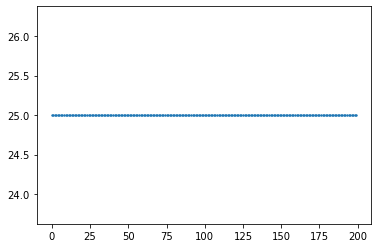

In [168]:
scenes_lenght = []
for scene in scenes_dict:
    scenes_lenght.append(len(scenes_dict[scene]))

x=[]
for i in range(0, len(scenes_dict)):
    x.append(i)
    
plt.scatter( x ,scenes_lenght, s=2)

In [167]:
restored_scene = last_scene

restored_scene_length = []
count_objects_not_restored = 0
count_objects_hallucinated = 0

objects_missing=[]
objects_hallicunated=[]

scene_id = 0

restored_scene_length = len(restored_scene)
for item in scenes_dict[scene_id]:
    if item not in restored_scene: 
        count_objects_not_restored+=1 
        objects_missing.append(item)
        
for item in restored_scene:
    if item not in scenes_dict[scene_id]:
        count_objects_hallucinated+=1;
        objects_hallicunated.append(item)
        
print('Original scene length: ', scenes_lenght[scene_id])
print('Restored scene length: ', restored_scene_length)
print('Objects not restored (MISSING): ', count_objects_not_restored)
print('Objects Hallicunated count: ', count_objects_hallucinated)

print('')

print('Scene original:', scenes_dict[scene_id])
print('Scene recaled:', restored_scene)

print('')

print('Missing objects:', objects_missing)
print('Hallicunated objects:', objects_hallicunated)

Original scene length:  25
Restored scene length:  28
Objects not restored (MISSING):  1
Objects Hallicunated count:  0

Scene original: [89, 178, 688, 180, 293, 260, 846, 219, 682, 191, 565, 629, 448, 195, 158, 165, 827, 574, 480, 831, 540, 365, 985, 62, 648]
Scene recaled: [89, 178, 180, 293, 260, 846, 219, 682, 191, 565, 629, 448, 195, 158, 165, 827, 574, 195, 158, 827, 574, 480, 831, 540, 365, 985, 62, 648]

Missing objects: [688]
Hallicunated objects: []


In [169]:
seed_scene_length = 6

scene_to_cut = scenes_dict[scene_id] 

objects_to_remove = len(scene_to_cut) - seed_scene_length
scene_to_cut = remove_random_elements_copy(scene_to_cut, objects_to_remove)
print(len(scene_to_cut))


seed = torch.tensor([scene_to_cut], dtype=torch.long)

seed = seed.to(device)
answer = m.generate( seed , max_new_tokens=2*block_size)[0].tolist()

6


In [617]:
len(scenes_dict)

1000

# ODZYSKANIE SCEN JEDNOKROTNE

In [ ]:
#DLA WSZYSTKICH SCEN
seed_scene_length = 6

restored_scenes_dict= {}
restored_scenes_missing_objects={}
restored_scenes_halicunated_objects={}

restored_scene_length = []
restored_scene_count_objects_restored=[]
restored_scene_count_objects_missing=[]
restored_scene_count_objects_hallucinated=[]
    
for scene_id in scenes_dict:
    print(f'\rProcessing scene {scene_id}/{len(scenes_dict)}', end=' ')
    restored_scenes_missing_objects[scene_id]=[]
    restored_scenes_halicunated_objects[scene_id]=[]
    
    scene_to_cut = scenes_dict[scene_id]
    objects_to_remove = len(scene_to_cut) - seed_scene_length
    scene_to_cut = remove_random_elements_copy(scene_to_cut, objects_to_remove)

    seed = torch.tensor([scene_to_cut], dtype=torch.long)
    seed = seed.to(device)
    
    while True:
        answer = m.generate( seed , max_new_tokens=2*block_size)[0].tolist()
        seed = torch.tensor([answer], dtype=torch.long)
        seed = seed.to(device)
    
        if 0 in answer:
            break

    last_zero_position = answer.index(0)

    #w przypadku gdy scene odzyska od razu
    last_one_position=-1
    for element in enumerate(answer[:(last_zero_position-1)]):
        if element[1] == 1:
            last_one_position = element[0]

    restored_scene = answer[last_one_position+1: last_zero_position-1]
    restored_scenes_dict[scene_id] = restored_scene
    restored_scene_length.append(len(set(restored_scene)))

    objects_restored = 0
    objects_missing = 0
    objects_hallucinated = 0

    for item in scenes_dict[scene_id]:
        if item in restored_scene:
            objects_restored+=1 
        else: 
            restored_scenes_missing_objects[scene_id].append(item)
            objects_missing+=1

    for item in restored_scene:
        if item not in scenes_dict[scene_id]:
            restored_scenes_halicunated_objects[scene_id].append(item)     
            objects_hallucinated+=1 

    restored_scene_count_objects_restored.append(objects_restored)
    restored_scene_count_objects_missing.append(objects_missing)
    restored_scene_count_objects_hallucinated.append(objects_hallucinated)

'''
print(restored_scene_objects_missing)
print(restored_scene_objects_hallucinated)
print('XXX')
print("Scene: ", scenes_dict[scene_id])
print("Restored: ", restored_scenes_dict[scene_id])
print('XXX')
print('Missing',restored_scenes_missing_objects[scene_id])
print('Halicunated',restored_scenes_halicunated_objects[scene_id])
'''    

# ODZYSKANIE SCEN -> *REPEATS* <-

In [171]:
#KOMORKA DO OBLICZEN DLA KILKU PROB
restored_scenes_dict_repeats = {}
restored_scenes_missing_objects_repeats={}
restored_scenes_halicunated_objects_repeats={}

restored_scene_length_repeats = {}
restored_scene_count_objects_restored_repeats={}
restored_scene_count_objects_missing_repeats={}
restored_scene_count_objects_hallucinated_repeats={}
    
    
for key in scenes_dict.keys():
    #Restored
    restored_scenes_dict_repeats[key]=[]
    #Restored counts
    restored_scene_length_repeats[key]=[]
    
    #Missing
    restored_scenes_missing_objects_repeats[key]=[]
    #Missing counts
    restored_scene_count_objects_missing_repeats[key]=[]
        
    #Halicunated
    restored_scenes_halicunated_objects_repeats[key]=[]
    #Halicunated counts
    restored_scene_count_objects_hallucinated_repeats[key]=[]
    
    
#DLA WSZYSTKICH SCEN
seed_scene_length = 6
repeats=15

for repeat in range(0,repeats):
    restored_scenes_dict= {}
    restored_scenes_missing_objects={}
    restored_scenes_halicunated_objects={}

    restored_scene_length = []
    restored_scene_count_objects_restored=[]
    restored_scene_count_objects_missing=[]
    restored_scene_count_objects_hallucinated=[]
    
    for scene_id in scenes_dict.keys():
        print(f'\rProcessing scene {scene_id}/{len(scenes_dict)} xxx Repeat {repeat}/{repeats}', end=' ')
        #print(f'Processing scene {scene_id}/{len(scenes_dict)} xxx Repeat {repeat}/{repeats}')
        #print(scene_id)
        
        restored_scenes_missing_objects[scene_id]=[]
        restored_scenes_halicunated_objects[scene_id]=[]

        scene_to_cut = scenes_dict[scene_id]
        objects_to_remove = len(scene_to_cut) - seed_scene_length
        scene_to_cut = remove_random_elements_copy(scene_to_cut, objects_to_remove)

        seed = torch.tensor([scene_to_cut], dtype=torch.long)
        seed = seed.to(device)

        while True:
            answer = m.generate( seed , max_new_tokens=2*block_size)[0].tolist()
            seed = torch.tensor([answer], dtype=torch.long)
            seed = seed.to(device)

            if 0 in answer:
                break

        last_zero_position = answer.index(0)
        
        #W PRZYPADKU GDY ODZYSKA PELNA SCENE OD RAZU
        last_one_position=-1
        for element in enumerate(answer[:(last_zero_position-1)]):
            if element[1] == 1:
                last_one_position = element[0]

        restored_scene = answer[last_one_position+1: last_zero_position-1]
        restored_scenes_dict[scene_id] = restored_scene
        restored_scene_length.append(len(set(restored_scene)))

        objects_restored = 0
        objects_missing = 0
        objects_hallucinated = 0

        for item in scenes_dict[scene_id]:
            if item in restored_scene:
                objects_restored+=1 
            else: 
                restored_scenes_missing_objects[scene_id].append(item)
                objects_missing+=1

        for item in restored_scene:
            if item not in scenes_dict[scene_id]:
                restored_scenes_halicunated_objects[scene_id].append(item)     
                objects_hallucinated+=1 

        restored_scene_count_objects_restored.append(objects_restored)
        restored_scene_count_objects_missing.append(objects_missing)
        restored_scene_count_objects_hallucinated.append(objects_hallucinated)
    
        #Restored
        restored_scenes_dict_repeats[scene_id].append(restored_scene)
        #Restored counts
        restored_scene_length_repeats[scene_id].append(len(set(restored_scene)))

        #Missing
        restored_scenes_missing_objects_repeats[scene_id].append(restored_scenes_missing_objects[scene_id])
        #Missing counts
        restored_scene_count_objects_missing_repeats[scene_id].append(objects_missing)

        #Halicunated
        restored_scenes_halicunated_objects_repeats[scene_id].append(restored_scenes_halicunated_objects[scene_id])
        #Halicunated counts
        restored_scene_count_objects_hallucinated_repeats[scene_id].append(objects_hallucinated)

'''
print(restored_scene_objects_missing)
print(restored_scene_objects_hallucinated)
print('XXX')
print("Scene: ", scenes_dict[scene_id])
print("Restored: ", restored_scenes_dict[scene_id])
print('XXX')
print('Missing',restored_scenes_missing_objects[scene_id])
print('Halicunated',restored_scenes_halicunated_objects[scene_id])
'''    

Processing scene 199/200 xxx Repeat 14/15 

'\nprint(restored_scene_objects_missing)\nprint(restored_scene_objects_hallucinated)\nprint(\'XXX\')\nprint("Scene: ", scenes_dict[scene_id])\nprint("Restored: ", restored_scenes_dict[scene_id])\nprint(\'XXX\')\nprint(\'Missing\',restored_scenes_missing_objects[scene_id])\nprint(\'Halicunated\',restored_scenes_halicunated_objects[scene_id])\n'

# ZAPIS MODELU

In [183]:
import pickle

# Save the lists to a file
with open('tmp_lists_history.pkl', 'wb') as file:
    pickle.dump((loss_history, val_history, learning_rate_hist, batch_size_hist), file)

In [39]:
model_parameters_count= sum(p.numel() for p in m.parameters())
model_parameters_count

2720794

In [40]:
print('para_'+str(model_parameters_count)+'___nemd_'+str(n_embd)+'___nhead_'+str(n_head)+'___nlayer_'+str(n_head)+'___dropout_'+str(dropout))

para_2720794___nemd_180___nhead_6___nlayer_6___dropout_0.3


In [186]:
#torch.save(model.state_dict(), 'm_para_7142797___nemd_300___nhead_10___nlayer_10___dropout_0.2.pth')

# WCZYTANIE MODELU

In [38]:
import pickle

# Restore the lists from the file
with open('tmp_lists_history.pkl', 'rb') as file:
    loaded_lists = pickle.load(file)

# Separate the restored lists
loss_history, val_history, learning_rate_hist, batch_size_hist = loaded_lists

In [43]:
import pickle 

#with open('m_para_7142797___nemd_300___nhead_10___nlayer_10___dropout_0.2.pkl', 'wb') as f:
 #   pickle.dump(restored_scenes_dict_repeats, f)

NameError: name 'restored_scenes_dict_repeats' is not defined

In [44]:
!ls -l  *.pkl

-rw-rw-r-- 1 marcin marcin      0 lut  6 09:02 m_para_7142797___nemd_300___nhead_10___nlayer_10___dropout_0.2.pkl
-rw-rw-r-- 1 marcin marcin      0 lut  6 08:59 para_2720794___nemd_180___nhead_6___nlayer_6___dropout_0.3.pkl
-rw-rw-r-- 1 marcin marcin 407576 lut  6 05:49 tmp_lists_history.pkl


In [173]:
print('restored')
for key in [0,1]:
    print('###KEY: ', key)
    for i in range(0,len(restored_scenes_dict_repeats[key])):
        print(restored_scenes_dict_repeats[key][i])
    
print('\nRestored lenght')
for key in [0,1]:
    print('###KEY: ', key)
    print(restored_scene_length_repeats[key])

    
print('\nMissing')
for key in [0,1]:
    print('###KEY: ', key)
    for i in range(0,len(restored_scenes_missing_objects_repeats[key])):
        print(restored_scenes_missing_objects_repeats[key][i])

print('\nMissing counts')
for key in [0,1]:
    print('###KEY: ', key)
    print(restored_scene_count_objects_missing_repeats[key])
    

    
print('\nHalicunated')
for key in [0,1]:
    print('###KEY: ', key)
    for i in range(0,len(restored_scenes_halicunated_objects_repeats[key])):
        print(restored_scenes_halicunated_objects_repeats[key][i])
        
print('\nHalicunated counts')
for key in [0,1]:
    print('###KEY: ', key)
    print(restored_scene_count_objects_hallucinated_repeats[key])

restored
###KEY:  0
[89, 178, 688, 180, 293, 260, 846, 219, 682, 191, 565, 629, 448, 195, 158, 165, 827, 574, 480, 831, 540, 365, 985, 62, 648]
[89, 178, 180, 293, 260, 846, 219, 191, 565, 629, 448, 195, 158, 165, 827, 574, 480, 831, 540, 365, 985, 62, 648]
[89, 178, 688, 180, 293, 260, 846, 682, 191, 565, 629, 448, 195, 158, 165, 827, 574, 480, 831, 365, 985, 62, 648]
[89, 178, 688, 180, 293, 260, 846, 219, 682, 985, 682, 191, 565, 629, 448, 195, 158, 165, 827, 574, 480, 831, 540, 365, 985, 62, 648]
[89, 178, 688, 180, 293, 260, 846, 219, 682, 191, 565, 629, 195, 158, 165, 827, 574, 480, 831, 540, 365, 985, 62, 648]
[89, 178, 293, 260, 846, 219, 191, 565, 448, 195, 158, 165, 827, 574, 480, 831, 540, 629, 448, 827, 480, 831, 540, 165, 827, 574, 480, 831, 540, 629, 985]
[261, 621, 522, 97, 895, 975, 223, 333, 539, 403, 171, 417, 103, 71, 625, 776, 964, 380, 952, 82, 547, 313, 293]
[178, 688, 180, 293, 846, 219, 682, 191, 565, 629, 448, 195, 158, 165, 827, 574, 480, 831, 540, 365, 985, 6

# ZAPIS WYNIKOW  *REPEATS*

In [652]:
model_parameters_count

7057232

In [654]:
import pickle 

date='_20240417'


file_names=['restored_scenes_dict_repeats', 
            'restored_scene_length_repeats',
            'restored_scenes_missing_objects_repeats',
            'restored_scene_count_objects_missing_repeats',
            'restored_scenes_halicunated_objects_repeats',
            'restored_scene_count_objects_hallucinated_repeats']

for i, dictionary in enumerate([restored_scenes_dict_repeats, 
                   restored_scene_length_repeats,
                   restored_scenes_missing_objects_repeats,
                   restored_scene_count_objects_missing_repeats,
                   restored_scenes_halicunated_objects_repeats,
                   restored_scene_count_objects_hallucinated_repeats]):
                                      
    with open(file_names[i]+str(model_parameters_count)+' '+date, 'wb') as f:
        pickle.dump(dictionary, f)          


In [174]:
objects_missing=0
objects_restored=0

for item in scenes_dict[scene_id]:
    
    if item in restored_scene:
        objects_restored+=1 
        #print('restored', item)
    else: 
        restored_scenes_missing_objects[scene_id].append(item)
        objects_missing+=1
        print('missing ', item)
        
print(objects_missing)

missing  899
1


In [175]:
#print(restored_scene_objects_restored)
#print(restored_scene_objects_missing)
#print(restored_scene_objects_hallucinated)
print('XXX')
print('Scene id: ', scene_id)
print('XXX')
print("Scene: ", scenes_dict[scene_id])
print("Restored: ", restored_scenes_dict[scene_id])
print('XXX')
print('Missing',restored_scenes_missing_objects[scene_id])
print('Halicunated',restored_scenes_halicunated_objects[scene_id])

XXX
Scene id:  199
XXX
Scene:  [559, 754, 289, 813, 613, 588, 899, 881, 657, 641, 449, 29, 172, 396, 238, 163, 196, 119, 763, 628, 600, 93, 196, 148, 437]
Restored:  [559, 754, 289, 813, 613, 588, 881, 657, 641, 449, 29, 172, 396, 238, 163, 196, 119, 763, 628, 600, 93, 196, 148, 437]
XXX
Missing [899, 899]
Halicunated []


# WYKRESY

In [176]:
rsc_om = [-len(restored_scenes_missing_objects[key]) for key in restored_scenes_missing_objects.keys()]
rsc_oh = [len(restored_scenes_halicunated_objects[key]) for key in restored_scenes_halicunated_objects.keys()]

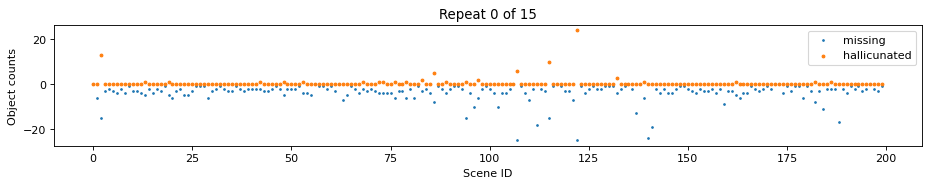

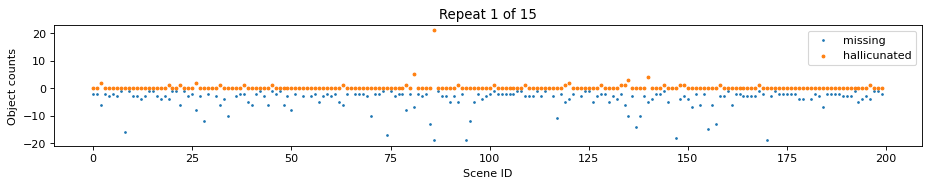

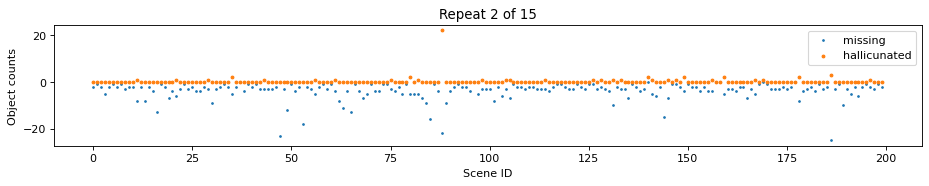

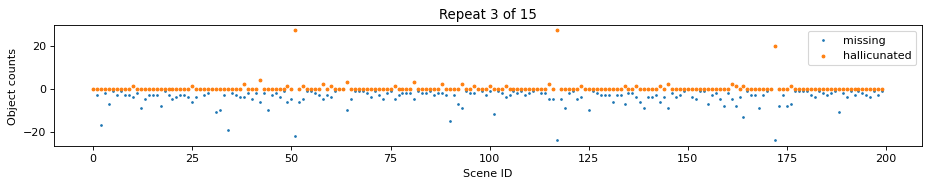

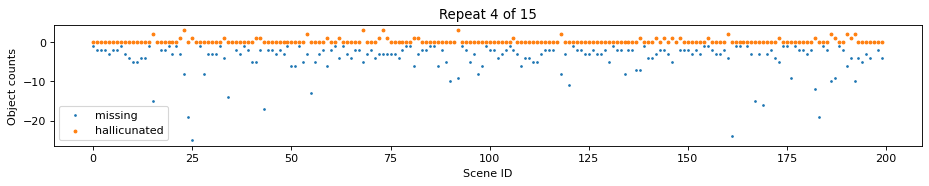

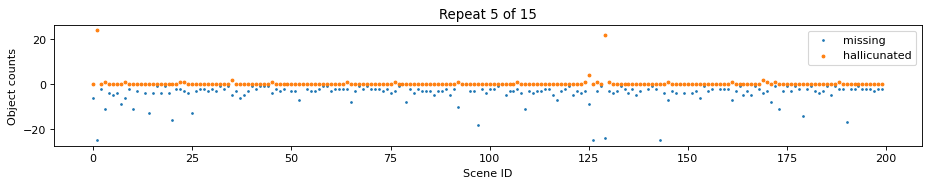

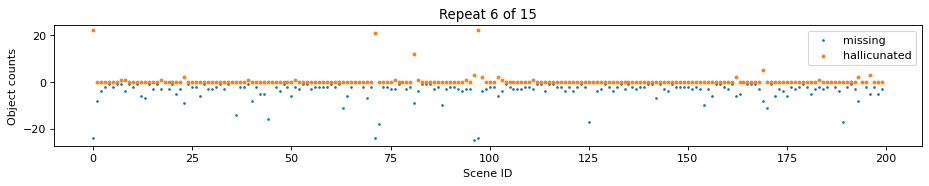

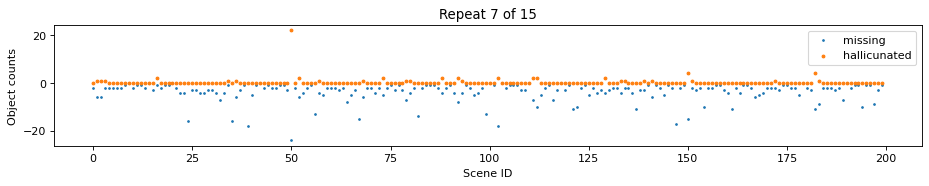

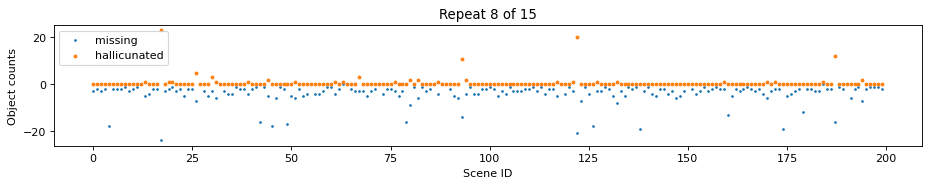

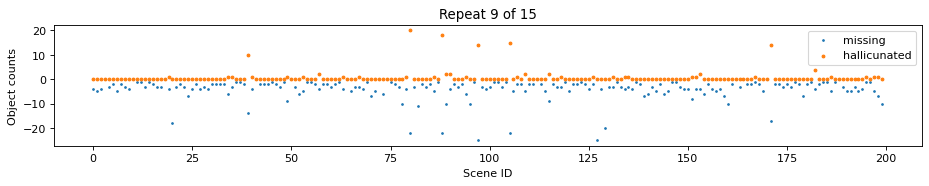

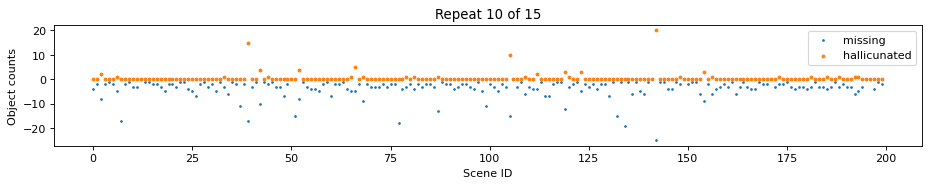

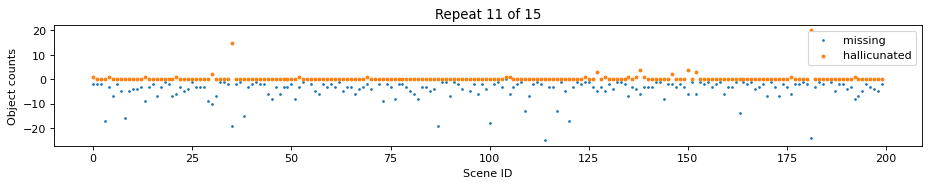

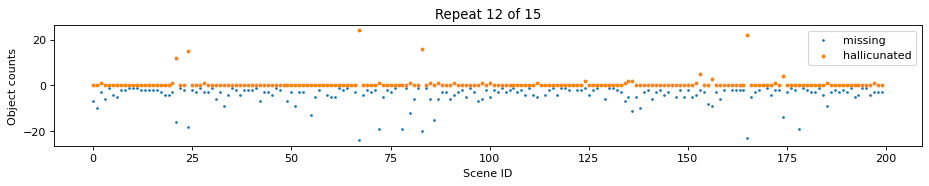

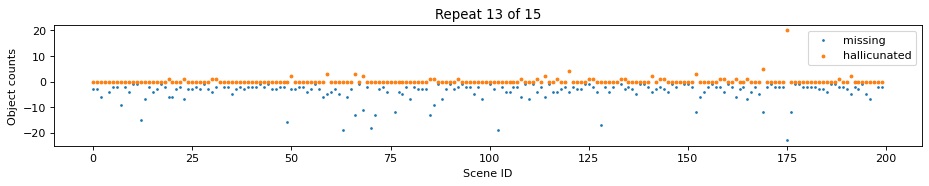

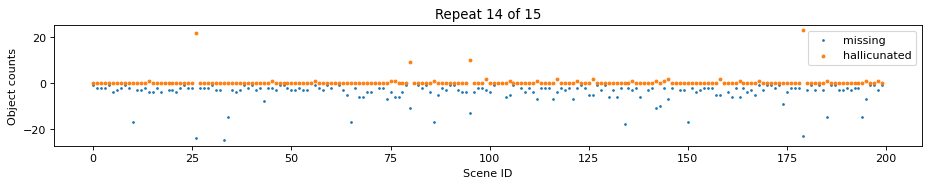

In [177]:
from matplotlib.pyplot import figure


for i in range(0, repeats):
    x=[]
    rsc_om=[]
    rsc_oh=[]

    for key in restored_scenes_dict_repeats.keys():
        x.append(key)
        rsc_om.append(-1*restored_scene_count_objects_missing_repeats[key][i])
        rsc_oh.append(restored_scene_count_objects_hallucinated_repeats[key][i])
    
    figure(figsize=(14, 2), dpi=80)
    plt.scatter(x, rsc_om, s= 2, label="missing")
    plt.scatter(x, rsc_oh, s=6, label="hallicunated")
    plt.title('Repeat '+str(i)+' of '+str(repeats))
    plt.xlabel('Scene ID')
    plt.ylabel('Object counts')
    plt.legend()
    plt.gcf().set_facecolor('white')
    plt.savefig('fig_2_'+str(i)+'.png')
    plt.show()
#print(len(x))
#print(len(rsc_om))

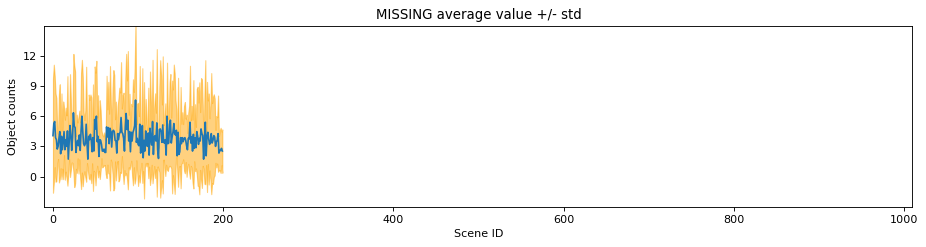

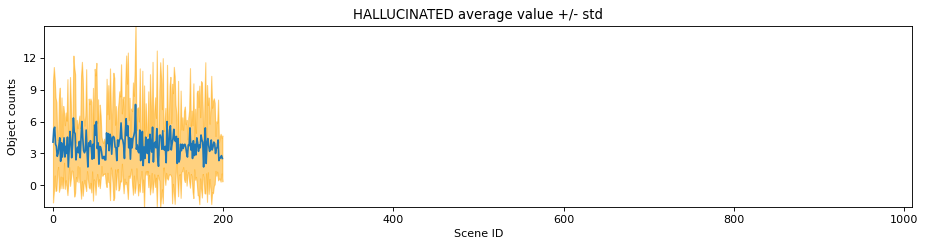

In [178]:
x=[]
rsc_om_avg=[]
rsc_om_std=[]
rsc_oh_avg=[]
rsc_oh_std=[]

for key in restored_scenes_dict_repeats.keys():
    x.append(key)
    rsc_om_avg.append(np.average(restored_scene_count_objects_missing_repeats[key][:]))
    rsc_om_std.append(np.std(restored_scene_count_objects_missing_repeats[key][:]))
    
    rsc_oh_avg.append(np.average(restored_scene_count_objects_missing_repeats[key][:]))
    rsc_oh_std.append(np.std(restored_scene_count_objects_missing_repeats[key][:]))


figure(figsize=(14, 3), dpi=80)
plt.title('MISSING average value +/- std')
plt.xlabel('Scene ID')
plt.ylabel('Object counts')
plt.axis([-10, 1010, -3, 15])
plt.yticks(np.arange(0, 15, 3.0))
plt.plot(x, rsc_om_avg, color='C0')
plt.fill_between(x,
                 [rsc_om_avg[i] - rsc_om_std[i] for i in range(0, len(rsc_om_avg))], 
                 [rsc_om_avg[i] + rsc_om_std[i] for i in range(0, len(rsc_om_avg))], 
                 color='orange', alpha=0.5)

plt.gcf().set_facecolor('white')
plt.savefig('fig_3_MISSING.png')
plt.show()

                      
figure(figsize=(14, 3), dpi=80)
plt.title('HALLUCINATED average value +/- std')
plt.xlabel('Scene ID')
plt.ylabel('Object counts')
plt.axis([-10, 1010, -2, 15])
plt.yticks(np.arange(0, 15, 3.0))
plt.plot(x, rsc_oh_avg, color='C0')
plt.fill_between(x,
                 [rsc_oh_avg[i] - rsc_oh_std[i] for i in range(0, len(rsc_oh_avg))], 
                 [rsc_oh_avg[i] + rsc_oh_std[i] for i in range(0, len(rsc_oh_avg))], 
                 color='orange', alpha=0.5)

plt.gcf().set_facecolor('white')
plt.savefig('fig_3_HALLUCINATED.png')
plt.show()

In [179]:
counts = 0
for i in range(0, repeats):
    
    for key in restored_scenes_dict_repeats.keys():
        #print('Key:',key)
        missing = True
        hallucinated = True
        
        if 0 == restored_scene_count_objects_missing_repeats[key][i]:
            missing = False
            
        if 0 == restored_scene_count_objects_hallucinated_repeats[key][i]:
            hallucinated = False
            
        if (missing == False) and (hallucinated==True):
            print('Full scene restored correctly', key)
            counts += 1
    print("XXXXXX")
print(counts)

XXXXXX
XXXXXX
Full scene restored correctly 140
Full scene restored correctly 169
XXXXXX
XXXXXX
XXXXXX
XXXXXX
XXXXXX
XXXXXX
Full scene restored correctly 63
Full scene restored correctly 184
XXXXXX
XXXXXX
XXXXXX
Full scene restored correctly 104
XXXXXX
XXXXXX
XXXXXX
XXXXXX
5


In [180]:
counts_how_many_missing = []
counts_how_many_hallicunated = []

for i in range(0, repeats):
    for key in restored_scenes_dict_repeats.keys():
        counts_how_many_missing.append(restored_scene_count_objects_missing_repeats[key][i])
        counts_how_many_hallicunated.append(restored_scene_count_objects_hallucinated_repeats[key][i])

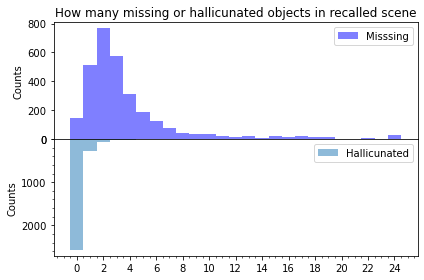

In [181]:
#plt.hist(counts_how_many_hallicunated, bins = np.arange(0,(max(counts_how_many_missing)+1),1))


# Create subplots with shared x-axis
fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0})

# Plot histogram for data1
#hist(data1, bins=30, 
axs[0].hist(counts_how_many_missing,bins = np.arange(0,(max(counts_how_many_missing)+1),1), 
            color='blue', alpha=0.5, label='Misssing', align='left')

# Plot histogram for data2 upside down
axs[1].hist(counts_how_many_hallicunated, bins = np.arange(0,(max(counts_how_many_missing)+1),1),
            alpha=0.5, label='Hallicunated', align='left')

axs[1].invert_yaxis()

# Add legend
axs[0].legend()
axs[1].legend()

# Add titles and labels
axs[0].set_title('How many missing or hallicunated objects in recalled scene')
axs[0].set_ylabel('Counts')
axs[1].set_ylabel('Counts')

#plt.axis([-2, 24, 0, 1100])
plt.xticks(np.arange(0, 25, 2.0))
# Set the length of major ticks on the x-axis
#plt.tick_params(axis='x', which='major', length=5)  # Adjust length as desired

# Set the length of minor ticks on the x-axis
#plt.tick_params(axis='x', which='minor', length=5)  # Adjust length as desired

plt.minorticks_on()
# Adjust layout
plt.tight_layout()

plt.gcf().set_facecolor('white')
plt.savefig('fig_4_Histogram.png')

# Show plot
plt.show()

In [182]:
from collections import Counter

# Count unique elements
unique_counts = Counter(counts_how_many_hallicunated)

# Print unique element counts
for element, count in unique_counts.items():
    print(f"{element}: {count}")

0: 2578
13: 1
1: 271
2: 69
5: 7
6: 1
10: 4
24: 3
3: 22
21: 2
4: 12
22: 7
27: 2
20: 6
12: 3
23: 2
11: 1
18: 1
14: 2
15: 4
16: 1
9: 1


(array([2.578e+03, 2.710e+02, 6.900e+01, 2.200e+01, 1.200e+01, 7.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 4.000e+00, 1.000e+00,
        3.000e+00, 1.000e+00, 2.000e+00, 4.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 6.000e+00, 2.000e+00, 7.000e+00, 2.000e+00,
        3.000e+00]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25]),
 <BarContainer object of 25 artists>)

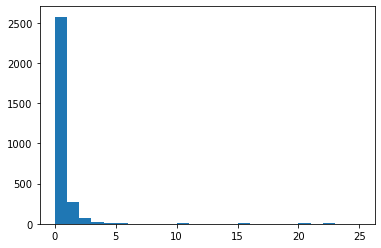

In [183]:
plt.hist(counts_how_many_hallicunated, bins = np.arange(0,(max(counts_how_many_missing)+1),1))

In [184]:
len(restored_scenes_dict_repeats)

200

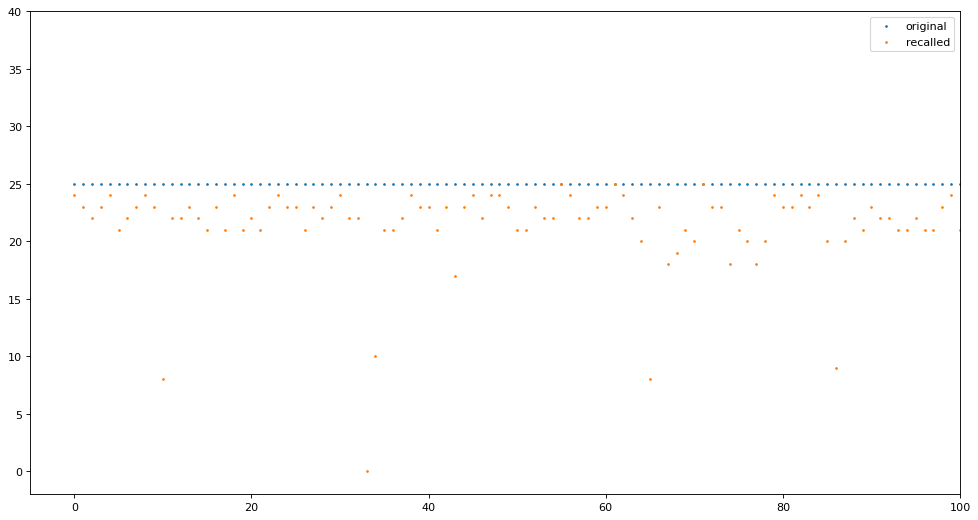

In [185]:
figure(figsize=(15, 8), dpi=80)

plt.scatter(x, scenes_lenght, s=2, label="original")
plt.scatter(x, restored_scene_length, s=2, label="recalled")
plt.axis([-5, 100, -2, 40])
plt.legend()
plt.show()

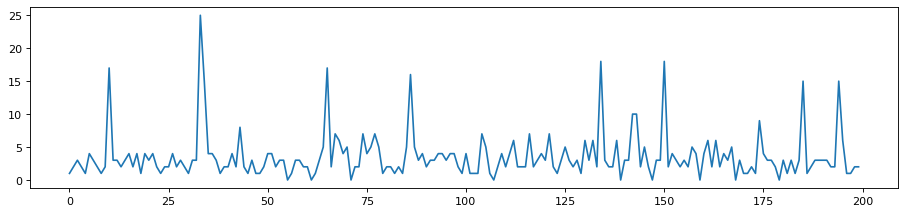

In [186]:
scenes_length_differences=[]

figure(figsize=(14, 3), dpi=80)
for i in range(0, len(scenes_lenght)):
    scenes_length_differences.append( scenes_lenght[i]-restored_scene_length[i] )

plt.plot(scenes_length_differences)

In [87]:
#torch.save(model.state_dict(), 'model_weights.pth')

In [105]:
model.load_state_dict(torch.load('m_para_7142797___nemd_300___nhead_10___nlayer_10___dropout_0.2.pth'))

RuntimeError: Error(s) in loading state_dict for BigramLanguageModel:
	size mismatch for position_embedding_table.weight: copying a param with shape torch.Size([150, 300]) from checkpoint, the shape in current model is torch.Size([200, 300]).
	size mismatch for blocks.0.sa.heads.0.tril: copying a param with shape torch.Size([150, 150]) from checkpoint, the shape in current model is torch.Size([200, 200]).
	size mismatch for blocks.0.sa.heads.1.tril: copying a param with shape torch.Size([150, 150]) from checkpoint, the shape in current model is torch.Size([200, 200]).
	size mismatch for blocks.0.sa.heads.2.tril: copying a param with shape torch.Size([150, 150]) from checkpoint, the shape in current model is torch.Size([200, 200]).
	size mismatch for blocks.0.sa.heads.3.tril: copying a param with shape torch.Size([150, 150]) from checkpoint, the shape in current model is torch.Size([200, 200]).
	size mismatch for blocks.0.sa.heads.4.tril: copying a param with shape torch.Size([150, 150]

In [104]:
!ls

batch_size_hist.png
learning_rate_hist.png
loss_history.png
model_p7057232
model_weights_para_2761226___nemd_180___nhead_9___nlayer_9___dropout_0_2
m_para_7142797___nemd_300___nhead_10___nlayer_10___dropout_0.2.pkl
m_para_7142797___nemd_300___nhead_10___nlayer_10___dropout_0.2.pth
nemd_180_nhead_6_nlayer_6_dropout_0_2
scenes_bin_vec.csv
sequences_pawel.csv
tmp_lists_history.pkl
untiled_31-Copy1.ipynb
untiled_31.ipynb
Untitled30.ipynb
Untitled.ipynb
val_history.png


# BRUDNOPIS

In [155]:
import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)

a = all_sequences[0:2]
print(all_sequences[0,999:1035].astype('int'))
#print(list(all_sequences[0].astype('int')))

[ 711  837  859  866  961  977  992  995 1016 1031    0   96  248  256
  259  261  355  464  465  469  491  495  530  551  561  571  610  882
  935 1025 1026 1032    0    1    2   53]


In [54]:
#batch_size=1
x, y = get_batch()
print('x: ',x[0])
print('y: ',y[0])
#tokens_to_generate = block_size - np.sum((x.clone().detach().cpu()).numpy()>0)


answer = m.generate(x, max_new_tokens=block_size)[0].tolist()

print(answer[:25])
print(answer[25:])
print('length:', len(answer))

x:  tensor([  54,  110,  134,  207,  240,  337,  340,  346,  449,  481,  482,  562,
         567,  714,  724,  818,  898, 1058, 1092,    0,    0,    0,    0,    0,
           0], device='cuda:0')
y:  tensor([  54,  110,  134,  207,  240,  337,  340,  346,  449,  481,  482,  562,
         567,  714,  724,  818,  898, 1058, 1092,    0,    0,    0,    0,    0,
           0], device='cuda:0')
[54, 110, 134, 207, 240, 337, 340, 346, 449, 481, 482, 562, 567, 714, 724, 818, 898, 1058, 1092, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
length: 50


In [55]:
seed = torch.tensor([[2, 64, 110, 210, 273, 416, 433, 442, 487, 506, 548, 592]], dtype=torch.long, device='cuda:0')
answer = m.generate( seed , max_new_tokens=3*block_size)[0].tolist()

print(answer)

[2, 64, 110, 210, 273, 416, 433, 442, 487, 506, 548, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 592, 806, 806, 806, 806, 806, 806, 806, 806, 806, 806, 806, 806, 806, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 352, 352, 352, 352, 352]


In [19]:
get_batch()

(tensor([[  7,  50,  65,  ...,   0,   0,   0],
         [ 90, 258, 260,  ...,   0,   0,   0],
         [  2, 258, 353,  ...,   0,   0,   0],
         ...,
         [ 66, 114, 242,  ...,   0,   0,   0],
         [ 49,  90, 210,  ...,   0,   0,   0],
         [214, 240, 241,  ...,   0,   0,   0]], device='cuda:0'),
 tensor([[   7,   50,   65,  ...,    0,    0,    0],
         [  84,   90,   96,  ...,    0,    0,    0],
         [   2,  258,  270,  ..., 1095,    0,    0],
         ...,
         [  66,  114,  242,  ..., 1095,    0,    0],
         [  49,   90,   94,  ...,    0,    0,    0],
         [ 113,  214,  240,  ...,    0,    0,    0]], device='cuda:0'))